# Normal Distribution Properties

**Module 3: Probability Distributions** | Lean Six Sigma Data Analytics

---

## The Normal Distribution

The **Normal Distribution** is:
- **Symmetrical** around the mean
- **Bell-shaped** (also called the "bell curve")
- Also known as the **Gauss curve** (after Carl Friedrich Gauss, 1777)

```
              ╱╲
             ╱  ╲
            ╱    ╲
           ╱      ╲
          ╱        ╲
         ╱          ╲
        ╱            ╲
    ───┴──────────────┴───
            μ
```

In [1]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# --- Minitab-style house style -------------------------------------------
import sys
from pathlib import Path as _Path

# minitab_style.py lives in the parent folder of each module directory
sys.path.append(str(_Path.cwd().parent))
import minitab_style as ms

ms.apply_style()

DATA_FILE = '../data/da-lss.xlsx'
xlsx = pd.ExcelFile(DATA_FILE)
print('Data loaded successfully!')


Data loaded successfully!


---

## Two Parameters of the Normal Distribution

A Normal Distribution has **two parameters** that determine its shape:

| Parameter | Symbol | Name | Effect |
|-----------|--------|------|--------|
| **Location** | μ (mu) | Mean | Determines the midpoint |
| **Dispersion** | σ (sigma) | Standard Deviation | Determines the spread |

---

## Effect of μ (Location Parameter)

Changing **μ** shifts the distribution left or right.

**Question:** Which distribution has the highest μ?

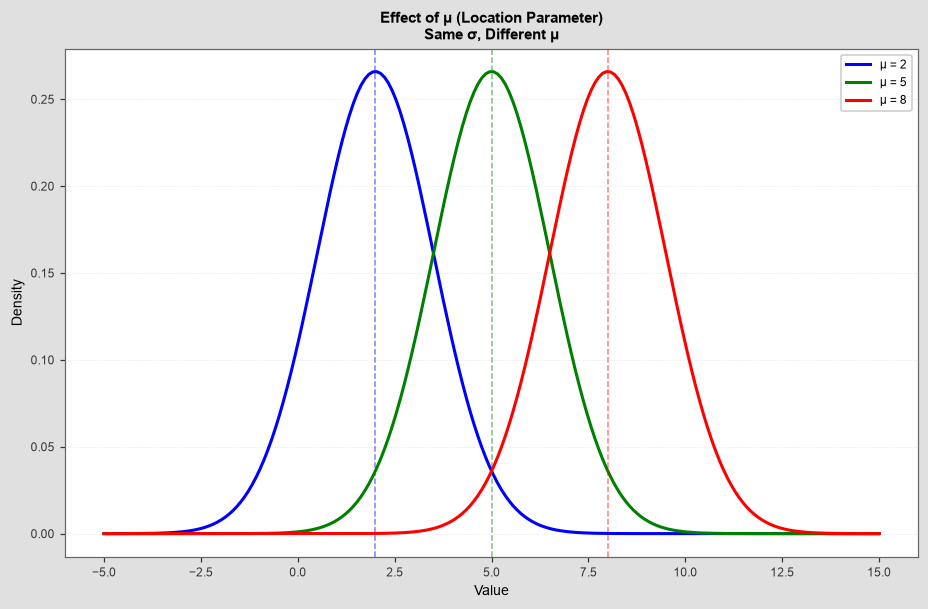

Answer: The RED distribution (most to the right) has the largest μ.
Changing μ shifts the distribution left or right.


In [2]:
# Effect of mu (location parameter)
fig, ax = plt.subplots(figsize=(10, 6))

x = np.linspace(-5, 15, 200)
sigma = 1.5  # Same sigma for all

# Three distributions with different mu values
for mu, color, label in [(2, 'blue', 'μ = 2'), (5, 'green', 'μ = 5'), (8, 'red', 'μ = 8')]:
    ax.plot(x, stats.norm.pdf(x, mu, sigma), color=color, lw=2, label=label)
    ax.axvline(x=mu, color=color, linestyle='--', alpha=0.5)

ax.set_xlabel('Value')
ax.set_ylabel('Density')
ax.set_title('Effect of μ (Location Parameter)\nSame σ, Different μ')
ax.legend()
plt.show()

print('Answer: The RED distribution (most to the right) has the largest μ.')
print('Changing μ shifts the distribution left or right.')

---

## Effect of σ (Dispersion Parameter)

Changing **σ** makes the distribution wider or narrower.

**Question:** Which distribution has the largest σ (largest spread)?

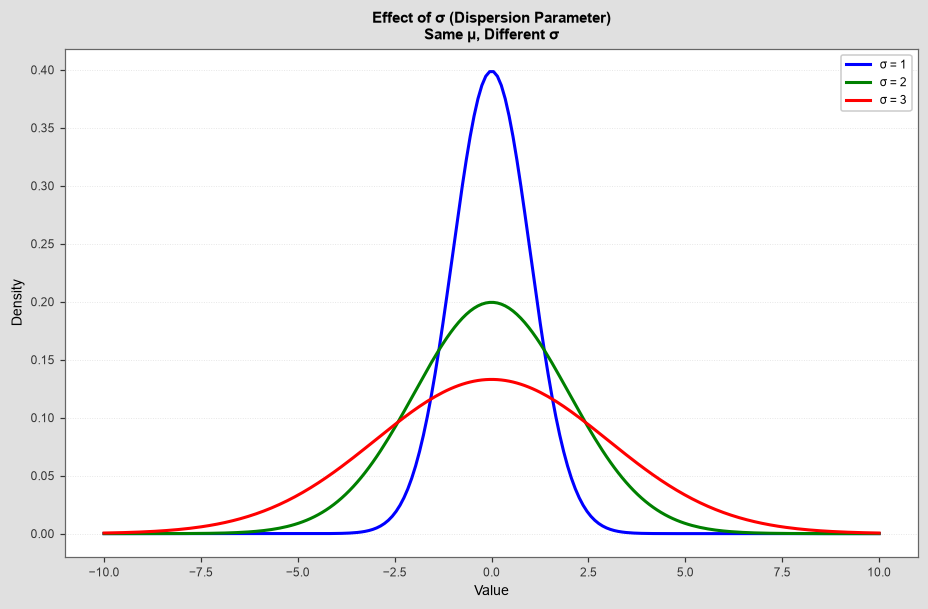

Answer: The RED distribution (most flattened out) has the largest σ.
Larger σ = wider spread, shorter peak.
Smaller σ = narrower spread, taller peak.


In [3]:
# Effect of sigma (dispersion parameter)
fig, ax = plt.subplots(figsize=(10, 6))

x = np.linspace(-10, 10, 200)
mu = 0  # Same mu for all

# Three distributions with different sigma values
for sigma, color, label in [(1, 'blue', 'σ = 1'), (2, 'green', 'σ = 2'), (3, 'red', 'σ = 3')]:
    ax.plot(x, stats.norm.pdf(x, mu, sigma), color=color, lw=2, label=label)

ax.set_xlabel('Value')
ax.set_ylabel('Density')
ax.set_title('Effect of σ (Dispersion Parameter)\nSame μ, Different σ')
ax.legend()
plt.show()

print('Answer: The RED distribution (most flattened out) has the largest σ.')
print('Larger σ = wider spread, shorter peak.')
print('Smaller σ = narrower spread, taller peak.')

---

## The 68-95-99-99.7 Rule (Empirical Rule)

For a normally distributed variable:

| Range | Percentage |
|-------|------------|
| μ ± 1σ | **68%** of the population |
| μ ± 2σ | **95%** of the population |
| μ ± 2.5σ | **99%** of the population |
| μ ± 3σ | **99.7%** of the population |

These are useful **rules of thumb** for calculations!

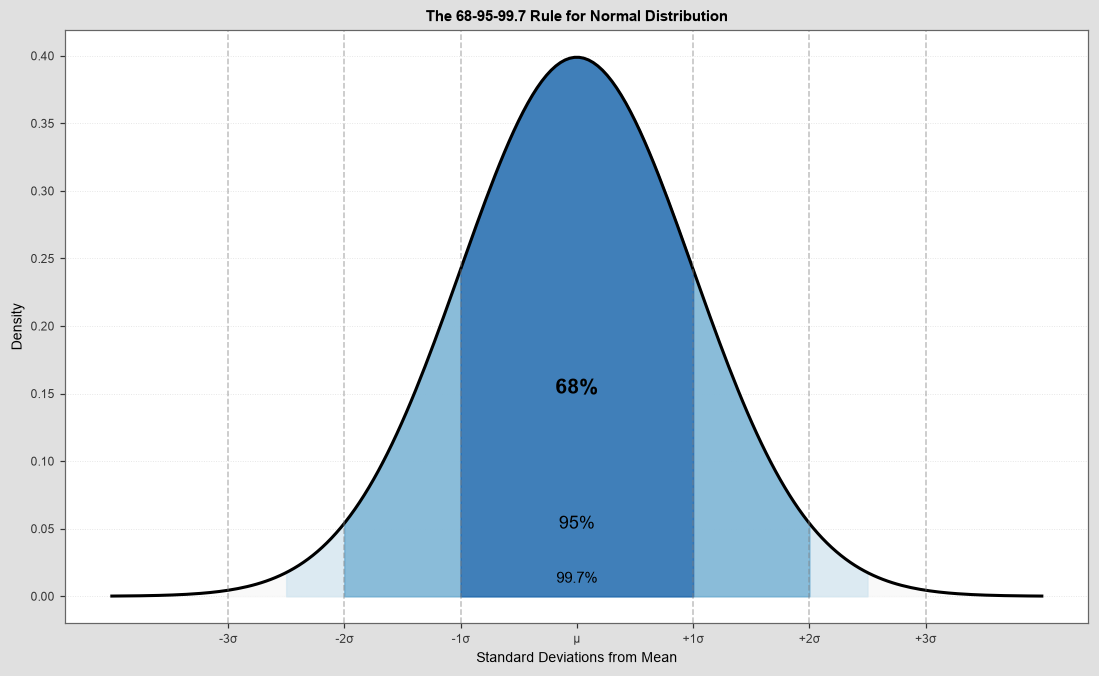

In [4]:
# Visualize the 68-95-99.7 rule
fig, ax = plt.subplots(figsize=(12, 7))

mu, sigma = 0, 1
x = np.linspace(-4, 4, 200)

# Plot the normal curve
ax.plot(x, stats.norm.pdf(x, mu, sigma), 'k-', lw=2)

# Fill areas for each range
colors = ['#2166ac', '#67a9cf', '#d1e5f0', '#f7f7f7']
labels = ['68% (±1σ)', '95% (±2σ)', '99% (±2.5σ)', '99.7% (±3σ)']
ranges = [(1, colors[0]), (2, colors[1]), (2.5, colors[2]), (3, colors[3])]

# Fill from outside in
for n_sigma, color in reversed(ranges):
    x_fill = np.linspace(-n_sigma, n_sigma, 100)
    ax.fill_between(x_fill, stats.norm.pdf(x_fill, mu, sigma), alpha=0.7, color=color)

# Add vertical lines and labels
for n_sigma, label in [(1, '68%'), (2, '95%'), (3, '99.7%')]:
    ax.axvline(x=-n_sigma, color='gray', linestyle='--', alpha=0.5)
    ax.axvline(x=n_sigma, color='gray', linestyle='--', alpha=0.5)

# Labels
ax.text(0, 0.15, '68%', ha='center', fontsize=14, fontweight='bold')
ax.text(0, 0.05, '95%', ha='center', fontsize=12)
ax.text(0, 0.01, '99.7%', ha='center', fontsize=10)

ax.set_xlabel('Standard Deviations from Mean')
ax.set_ylabel('Density')
ax.set_title('The 68-95-99.7 Rule for Normal Distribution')
ax.set_xticks([-3, -2, -1, 0, 1, 2, 3])
ax.set_xticklabels(['-3σ', '-2σ', '-1σ', 'μ', '+1σ', '+2σ', '+3σ'])
plt.show()

In [5]:
# Verify the percentages using scipy
print('VERIFICATION OF THE EMPIRICAL RULE')
print('=' * 50)
print()

for n_sigma, expected in [(1, 68), (2, 95), (2.5, 99), (3, 99.7)]:
    # Calculate actual percentage within ±n_sigma
    actual = (stats.norm.cdf(n_sigma) - stats.norm.cdf(-n_sigma)) * 100
    print(f'μ ± {n_sigma}σ: {actual:.2f}% (rule of thumb: ~{expected}%)')

VERIFICATION OF THE EMPIRICAL RULE

μ ± 1σ: 68.27% (rule of thumb: ~68%)
μ ± 2σ: 95.45% (rule of thumb: ~95%)
μ ± 2.5σ: 98.76% (rule of thumb: ~99%)
μ ± 3σ: 99.73% (rule of thumb: ~99.7%)


---

## Example: Caffeine Percentage in Coffee

The caffeine percentage in coffee follows a **Normal Distribution** with:
- Mean (μ) = 0.083
- Standard Deviation (σ) = 0.016

Using the rules of thumb, we can calculate ranges for the population.

In [6]:
# Load caffeine data to verify parameters
caffeine = pd.read_excel(xlsx, sheet_name='Caffeine_batches', skiprows=6, usecols=[0, 1])
caffeine.columns = ['Batch', 'Caffeine_Pct']
caffeine = caffeine.dropna()
caffeine['Caffeine_Pct'] = pd.to_numeric(caffeine['Caffeine_Pct'], errors='coerce')
caffeine = caffeine.dropna()

data = caffeine['Caffeine_Pct']

print('Caffeine Percentage Data')
print(f'Sample size: {len(data)}')
print(f'Mean (μ): {data.mean():.3f}')
print(f'Std Dev (σ): {data.std():.3f}')

Caffeine Percentage Data
Sample size: 40
Mean (μ): 0.083
Std Dev (σ): 0.016


In [7]:
# Apply the 68-95-99-99.7 rule to caffeine data
mu = 0.083
sigma = 0.016

print('APPLYING THE EMPIRICAL RULE TO CAFFEINE DATA')
print('=' * 60)
print(f'Mean (μ) = {mu}')
print(f'Std Dev (σ) = {sigma}')
print()

rules = [
    (1, 68),
    (2, 95),
    (2.5, 99),
    (3, 99.7)
]

for n_sigma, pct in rules:
    lower = mu - n_sigma * sigma
    upper = mu + n_sigma * sigma
    print(f'{pct}% of all coffee will have caffeine between {lower:.3f} and {upper:.3f}')

APPLYING THE EMPIRICAL RULE TO CAFFEINE DATA
Mean (μ) = 0.083
Std Dev (σ) = 0.016

68% of all coffee will have caffeine between 0.067 and 0.099
95% of all coffee will have caffeine between 0.051 and 0.115
99% of all coffee will have caffeine between 0.043 and 0.123
99.7% of all coffee will have caffeine between 0.035 and 0.131


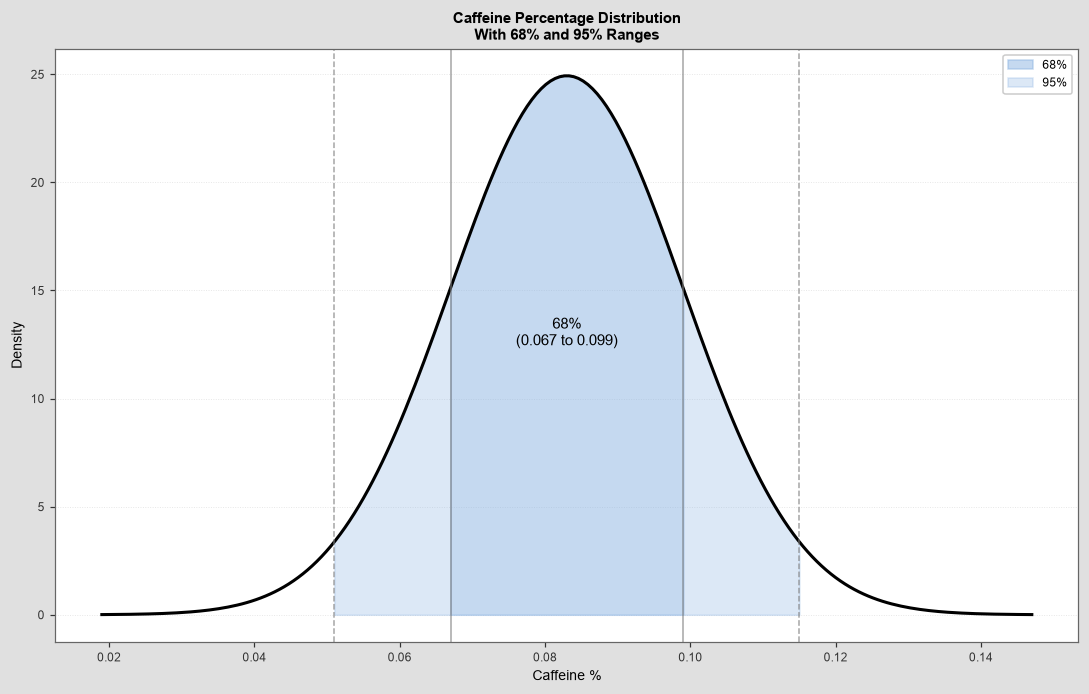

In [8]:
# Visualize the caffeine distribution with ranges
fig, ax = plt.subplots(figsize=(12, 7))

# Plot normal curve
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 200)
ax.plot(x, stats.norm.pdf(x, mu, sigma), 'k-', lw=2)

# Fill 68% range
x_68 = np.linspace(mu - sigma, mu + sigma, 100)
ax.fill_between(x_68, stats.norm.pdf(x_68, mu, sigma), alpha=0.5, color=ms.HIST_FILL, label='68%')

# Fill 95% range (outside 68%)
x_95_left = np.linspace(mu - 2*sigma, mu - sigma, 50)
x_95_right = np.linspace(mu + sigma, mu + 2*sigma, 50)
ax.fill_between(x_95_left, stats.norm.pdf(x_95_left, mu, sigma), alpha=0.3, color=ms.HIST_FILL, label='95%')
ax.fill_between(x_95_right, stats.norm.pdf(x_95_right, mu, sigma), alpha=0.3, color=ms.HIST_FILL)

# Add vertical lines for key ranges
for n, style in [(1, '-'), (2, '--')]:
    ax.axvline(x=mu - n*sigma, color='gray', linestyle=style, alpha=0.7)
    ax.axvline(x=mu + n*sigma, color='gray', linestyle=style, alpha=0.7)

# Annotations
ax.annotate(f'68%\n({mu-sigma:.3f} to {mu+sigma:.3f})', 
            xy=(mu, stats.norm.pdf(mu, mu, sigma)*0.5), ha='center', fontsize=10)

ax.set_xlabel('Caffeine %')
ax.set_ylabel('Density')
ax.set_title('Caffeine Percentage Distribution\nWith 68% and 95% Ranges')
ax.legend()
plt.show()

---

## Summary Table: Caffeine Percentage Ranges

In [9]:
# Summary table
print('SUMMARY: Caffeine Percentage Ranges')
print('=' * 60)
print(f'{"Range":<15} {"Lower":<10} {"Upper":<10} {"Interpretation"}')
print('-' * 60)

for n_sigma, pct in rules:
    lower = mu - n_sigma * sigma
    upper = mu + n_sigma * sigma
    print(f'{pct}% (±{n_sigma}σ)'.ljust(15) + f'{lower:.3f}'.ljust(10) + f'{upper:.3f}'.ljust(10) + 
          f'{pct}% of coffee in this range')

SUMMARY: Caffeine Percentage Ranges
Range           Lower      Upper      Interpretation
------------------------------------------------------------
68% (±1σ)      0.067     0.099     68% of coffee in this range
95% (±2σ)      0.051     0.115     95% of coffee in this range
99% (±2.5σ)    0.043     0.123     99% of coffee in this range
99.7% (±3σ)    0.035     0.131     99.7% of coffee in this range


---

## Key Takeaways

- **Normal Distribution** is symmetrical and bell-shaped (Gauss curve)
- **Two parameters:**
  - μ (mu) = location/mean → shifts distribution left/right
  - σ (sigma) = dispersion/spread → makes distribution wider/narrower
- **68-95-99-99.7 Rule:**
  - 68% within μ ± 1σ
  - 95% within μ ± 2σ
  - 99% within μ ± 2.5σ
  - 99.7% within μ ± 3σ
- These rules of thumb are useful for quick calculations